## ASL Classification using MobineNetV3Small (Transfer Learning)

Use American Sign Language(ASL) dataset to get a better understanding of Transfer Learning using the MobineNetV3Small model architecture. Since the dataset contains different hnd signals, which are not a part of the ImageNet dataset, it is expected that transfer learning will be less effective. 

In [1]:
import requests
import zipfile

import numpy as np
from dataclasses import dataclass

import tensorflow as tf
import keras
from keras.utils import image_dataset_from_directory

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

### Download the dataset

In [4]:
def downloadDataset(url, fileName):
    file = requests.get(url)

    open(fileName, "wb").write(file.content)


def unzipFile(zippedFileName=None):
    try:
        with zipfile.ZipFile(zippedFileName) as z:
            z.extractall("./")
            print("Extracted completely")
    except:
        print("Invalid file")

In [ ]:
downloadDataset(
    "https://www.dropbox.com/s/7huaqeavdbz32la/dataset_ASL_150.zip?dl=1",
    "dataset_ASL_150.zip",
)

unzipFile(zippedFileName="dataset_ASL_150.zip")

Extracted completely


### Dataset and Traning Config

In [3]:
@dataclass(frozen=True)
class DatasetConfig:
    IMG_HEIGHT: int = 224
    IMG_WIDTH: int = 224
    CHANNELS: int = 3
    NUM_CLASSES: int = 29
    BATCH_SIZE: int = 32
    DATA_ROOT: str = "./../dataset"


@dataclass(frozen=True)
class TrainingConfig:
    LEARNING_RATE: int = 0.0001
    EPOCHS: int = 25
    CHECKPOINT_FILEPATH: str = (
        "./classification_asl_mobineNetv3Small_transfer_learning.keras"
    )

### VGG-16 Model

In [4]:
inputShape = (DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH, DatasetConfig.CHANNELS)

convBase = keras.applications.MobileNetV3Small(
    include_top=False, weights="imagenet", input_shape=inputShape
)
convBase.trainable = False
print(convBase.summary())

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV3Small"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 56, 56,    │        256 │ expanded_conv_sq

 Total params: 939,120 (3.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 939,120 (3.58 MB)

None


In [5]:
# Add the classification layer
inputs = keras.Input(shape=inputShape)

x = keras.applications.mobilenet_v3.preprocess_input(inputs)
x = convBase(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation="relu")(x)
outputs = keras.layers.Dense(DatasetConfig.NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     7,225,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,172,173 (31.17 MB)

 Trainable params: 7,233,053 (27.59 MB)

 Non-trainable params: 939,120 (3.58 MB)

None


### Prepare the datasets

In [6]:
trainDataset = image_dataset_from_directory(
    DatasetConfig.DATA_ROOT,
    batch_size=DatasetConfig.BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    image_size=inputShape[:2],
    seed=42,
    validation_split=0.2,
    subset="training",
)
validDataset = image_dataset_from_directory(
    DatasetConfig.DATA_ROOT,
    batch_size=DatasetConfig.BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    image_size=inputShape[:2],
    seed=42,
    validation_split=0.2,
    subset="validation",
)

Found 4350 files belonging to 29 classes.
Using 3480 files for training.
Found 4350 files belonging to 29 classes.
Using 870 files for validation.


### Display sample images

2025-12-11 15:53:25.466838: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


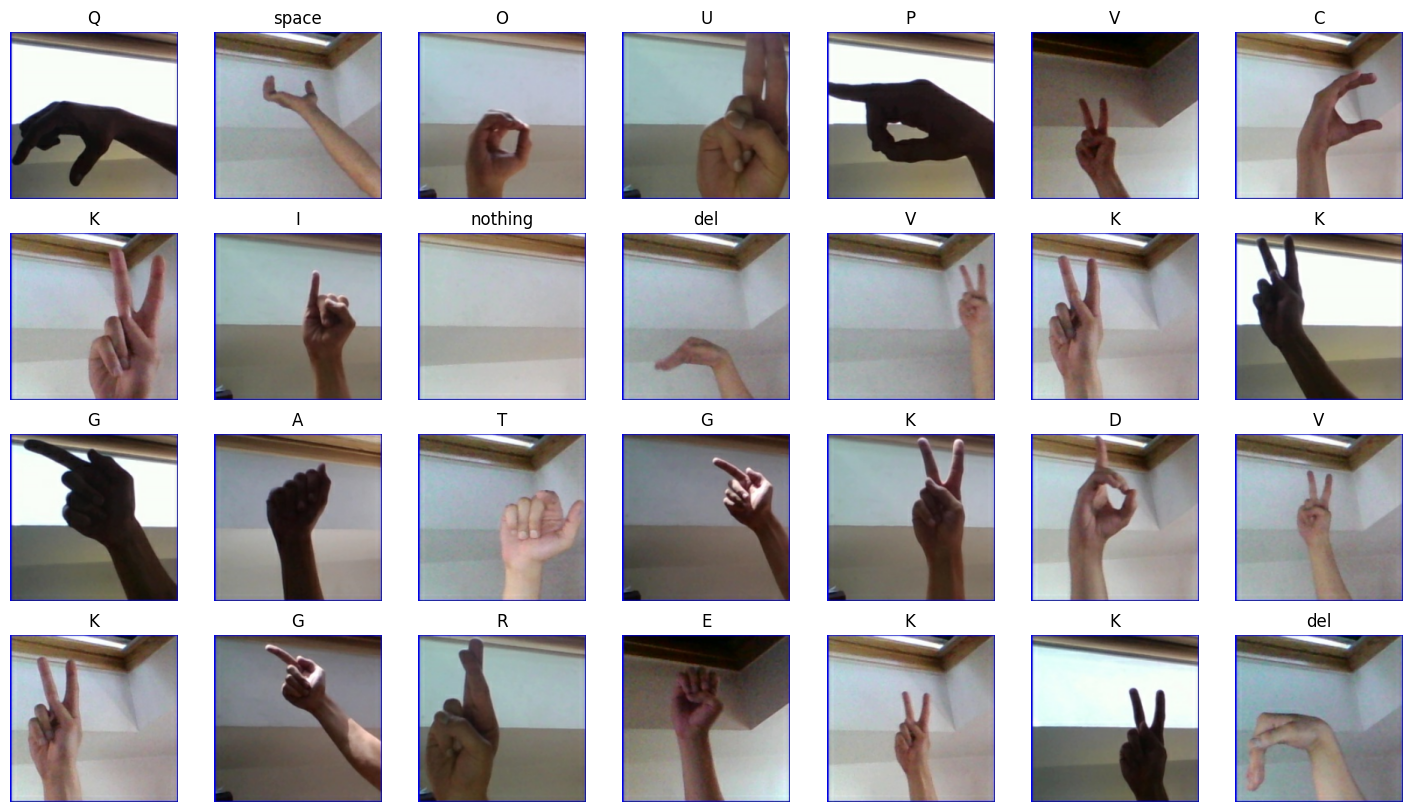

In [7]:
classNames = trainDataset.class_names

numRows = 4
numCols = 7

plt.figure(figsize=(18, 10))
for imagesBatch, labelsBatch in trainDataset.take(1):
    for i in range(numRows * numCols):
        ax = plt.subplot(numRows, numCols, i + 1)
        plt.imshow(imagesBatch[i].numpy().astype("uint8"))

        truthIndex = np.nonzero(labelsBatch[i].numpy())
        plt.title(classNames[truthIndex[0][0]])
        plt.axis("off")

plt.show()
plt.close()

### Base Model Evaluation before final training

Compile and evaluate the model before the dense classifier is trained.

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=TrainingConfig.LEARNING_RATE),
    loss=keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

In [9]:
print(
    f"Model accuracy before final training: {model.evaluate(validDataset)[1]*100:.3f}"
)

28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.0287 - loss: 5.3510
Model accuracy before final training: 2.874


### Train the model

In [10]:
modelCheckpointCallback = keras.callbacks.ModelCheckpoint(
    TrainingConfig.CHECKPOINT_FILEPATH,
    save_best_only=True,
    save_weights_only=False,
    monitor="val_accuracy",
    mode="max",
)

trainingResults = model.fit(
    trainDataset,
    epochs=TrainingConfig.EPOCHS,
    callbacks=modelCheckpointCallback,
    validation_data=validDataset,
)

Epoch 1/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.6011 - loss: 1.5593 - val_accuracy: 0.8483 - val_loss: 0.5381
Epoch 2/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.9718 - loss: 0.1243 - val_accuracy: 0.9126 - val_loss: 0.3408
Epoch 3/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.9974 - loss: 0.0233 - val_accuracy: 0.9276 - val_loss: 0.2966
Epoch 4/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.9994 - loss: 0.0090 - val_accuracy: 0.9322 - val_loss: 0.2733
Epoch 5/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 0.9299 - val_loss: 0.2659
Epoch 6/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.9310 - val_loss: 0.2608
Epoch 7/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9310 - val_loss: 0.2586
Epoch 8/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 1.0000 - loss: 0.0020

### Plot the metrics

In [11]:
def plotMetrics(metrics, metricsName=None, yLabel=None, yLim=None, colours=None):
    if not (isinstance(metricsName, list) or isinstance(metricsName, tuple)):
        metricsName = [
            metricsName,
        ]
        metric = [
            metrics,
        ]
        colours = [
            colours,
        ]

    plt.figure(figsize=(15, 4))

    for idx, metric in enumerate(metrics):
        plt.plot(metric, color=colours[idx], label=metricsName[idx])

    # plt.xlabel(xlabel="Epoch")
    plt.xlim(0, TrainingConfig.EPOCHS - 1)
    # plt.ylabel(ylabel=yLabel)
    plt.ylim(yLim)
    plt.title(yLabel)
    plt.grid(True)

    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    plt.show(block=False)
    plt.close()

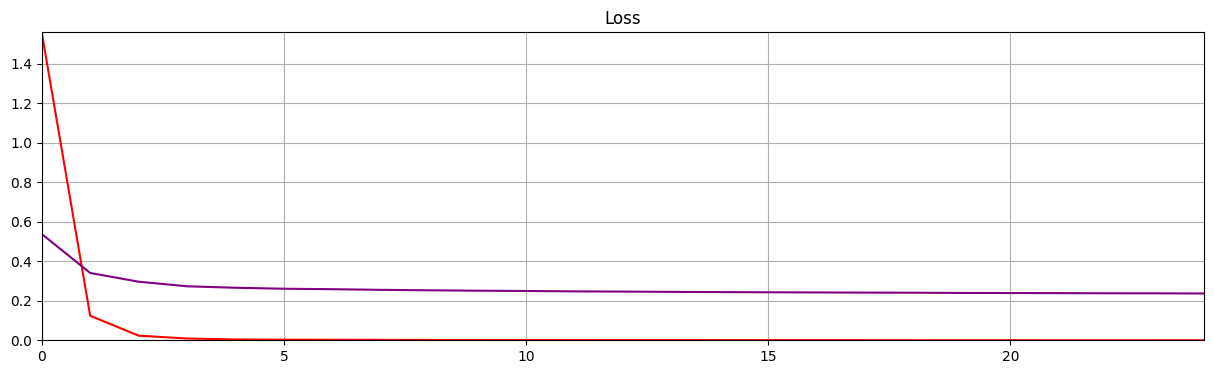

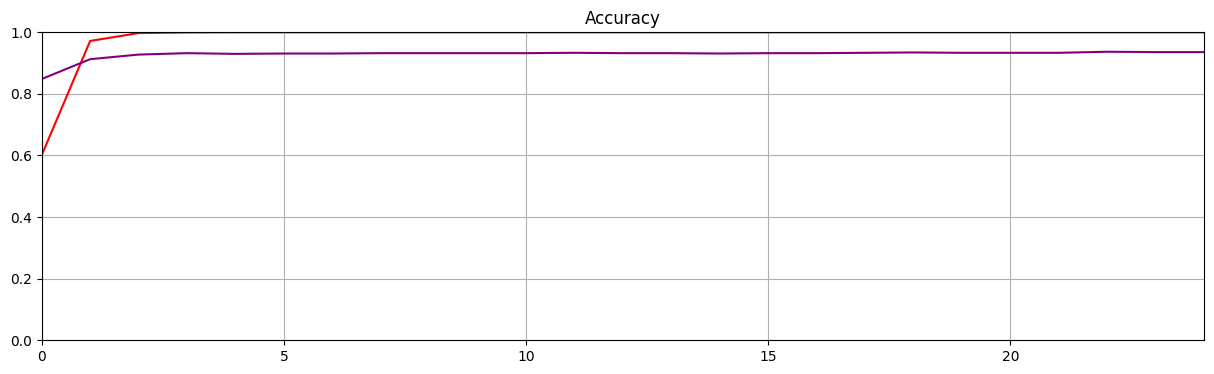

In [12]:
loss = trainingResults.history["loss"]
val_loss = trainingResults.history["val_loss"]
accuracy = trainingResults.history["accuracy"]
val_accuracy = trainingResults.history["val_accuracy"]

plotMetrics(
    [loss, val_loss],
    ["Training Loss", "Validation Loss"],
    yLabel="Loss",
    yLim=(0, max(max(loss), max(val_loss))),
    colours=["red", "purple"],
)
plotMetrics(
    [accuracy, val_accuracy],
    ["Training Accuracy", "Validation Accuracy"],
    yLabel="Accuracy",
    yLim=(0, 1.0),
    colours=["red", "purple"],
)

### Model Evaluation

In [13]:
savedModel = keras.models.load_model(TrainingConfig.CHECKPOINT_FILEPATH)

print(f"Saved best model accuracy: {savedModel.evaluate(validDataset)[1]*100:.3f}%")

28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9368 - loss: 0.2379
Saved best model accuracy: 93.678%


In [14]:
def displayWrongPredictions(model, dataset):
    numRows = 4
    numCols = 8
    wrongPredictionsCount = 0

    plt.figure(figsize=(20, 15))
    for imagesBatch, labelsBatch in dataset:
        predictions = model.predict(imagesBatch)
        for idx, label in enumerate(labelsBatch):
            truthIndex = np.nonzero(label.numpy())
            predictionIndex = tf.argmax(predictions[idx]).numpy()

            if truthIndex == predictionIndex:
                continue

            wrongPredictionsCount += 1

            if wrongPredictionsCount > numRows * numCols:
                break

            ax = plt.subplot(numRows, numCols, wrongPredictionsCount)
            title = (
                str(classNames[predictionIndex])
                + " : "
                + str(classNames[truthIndex[0][0]])
            )
            titleObj = plt.title(title)

            plt.setp(titleObj, color="red")
            plt.axis("off")
            plt.imshow(imagesBatch[idx].numpy().astype("uint8"))
    # return

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━

2025-12-11 15:59:17.933081: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


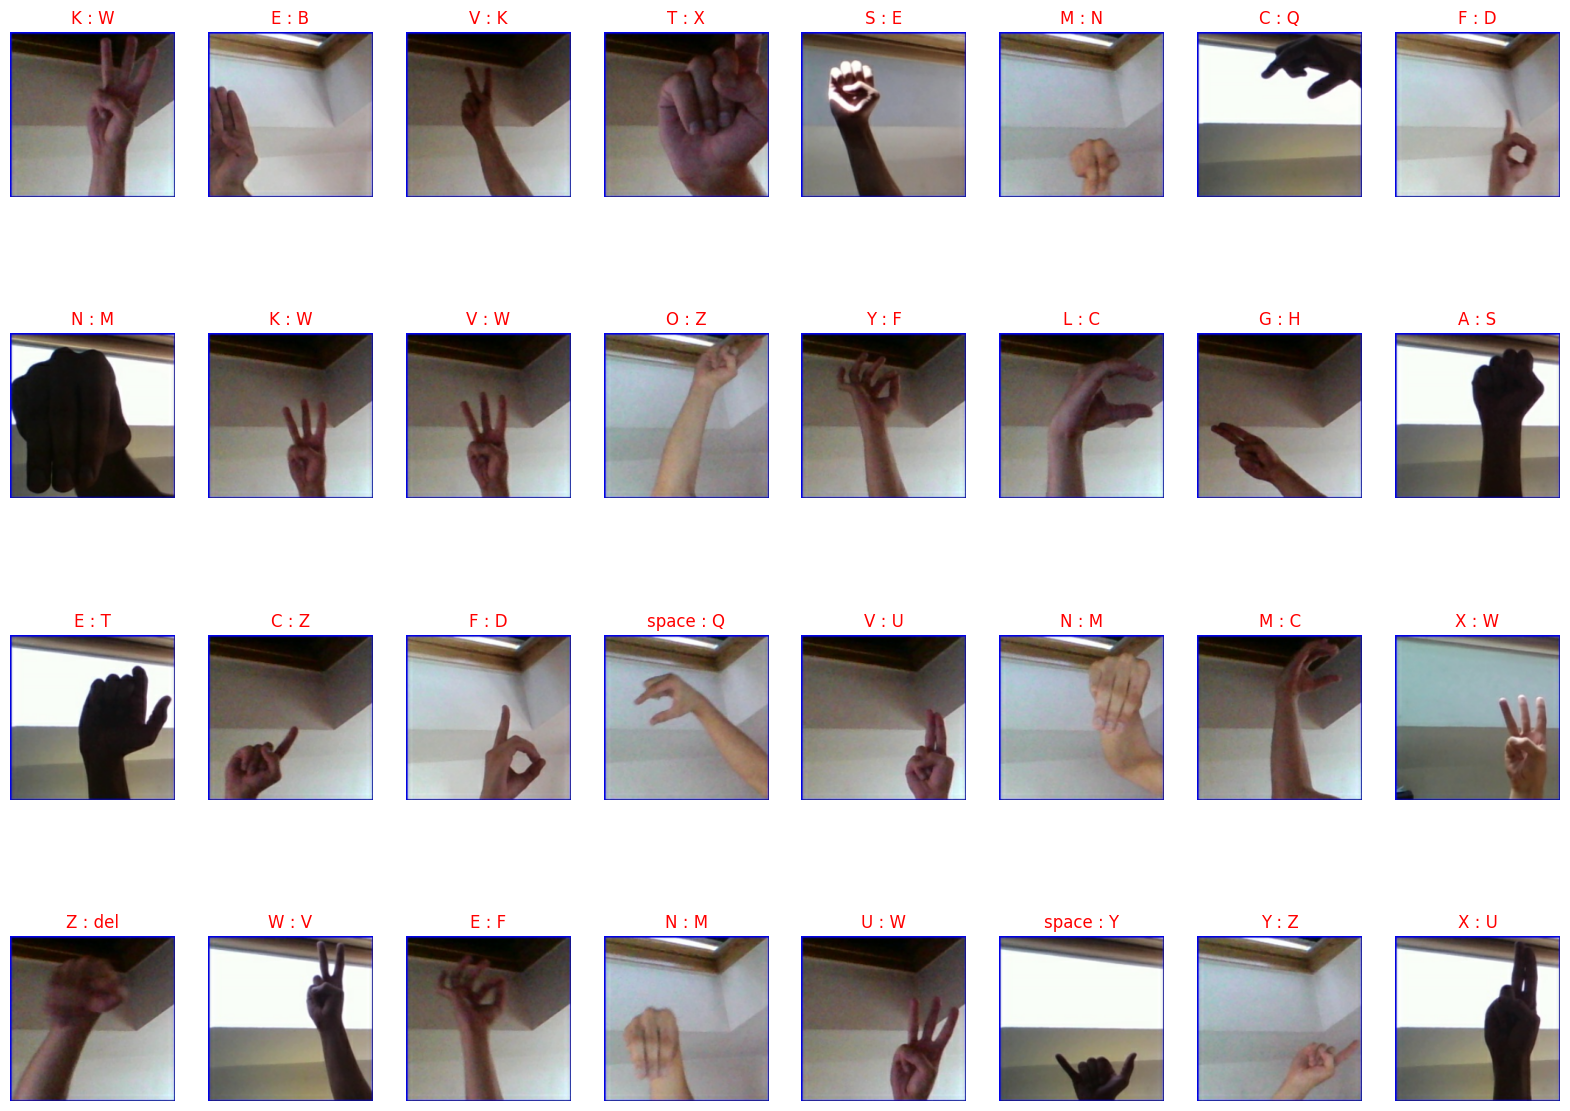

In [15]:
displayWrongPredictions(savedModel, validDataset)